# 3D Tumor Coupling — tissue visualization (ipyvolume)

Interactive 3D view of the tumor grown in **`tumor_coupling_3d.py`** (a COPASI
population ODE driving a volumetric tyssue monolayer). This notebook **loads the
saved history** `outputs/monolayer_tumor_history.hf5` and draws the tissue's
**apical surface** with tyssue's `browse_history` — a single-layer sheet (one
polygon per cell) so the coloured faces and the wireframe cell outlines coincide.
Each cell is coloured by `cell_type`: **tumor cells in red** and the seeded **cancer
stem cells in purple**, against the blue healthy epithelium. Drag the slider through
time and watch the stem focus seed a tumor that divides into a 3D mass — the randomized division-plane orientations push it
out of the starting plane, buckling the surface in *z*.

> This notebook does **not** run the simulation — run `python tumor_coupling_3d.py`
> first (from this directory) to produce the history file.

Requires `ipyvolume` (already in the `vivarium-tyssue` env). In JupyterLab you may
need the widgets extension enabled for the 3D canvas to appear.

## The simulation

Two models run side by side and are coupled one way: a **continuum tumour-population
ODE** (COPASI / SBML) sets the *rates*, and a **3-D volumetric vertex model**
(tyssue monolayer) carries out the resulting discrete cell events.

### Mechanics — 3-D monolayer vertex model

Cells are volumetric polyhedra $\alpha$ with volume $V_\alpha$; their faces $\phi$
have area $A_\phi$ and perimeter $P_\phi$, and edges $\langle ij\rangle$ have
length $\ell_{ij}$. The energy is

$$
E \;=\; \sum_{\alpha} \frac{K_V}{2}\left(V_\alpha - V_{0,\alpha}\right)^2
   \;+\; \sum_{\phi}\left[\frac{K_A}{2}\left(A_\phi - A_0\right)^2
   \;+\; \frac{K_P}{2}\,P_\phi^{2}\right]
   \;+\; \frac{1}{2}\sum_{\langle ij\rangle}\Lambda_{ij}\,\ell_{ij},
$$

(cell-volume elasticity, face-area elasticity, face contractility and line
tension), relaxed in the overdamped limit

$$
\eta\,\frac{\mathrm{d}\mathbf{r}_i}{\mathrm{d}t} \;=\; -\frac{\partial E}{\partial \mathbf{r}_i},
$$

with a forward-Euler step $\Delta t$ and T1 neighbour swaps below
$\ell_{\min}$ (so the confluent tissue can rearrange around a growing cell).

### Tumour-population ODE

`BIOMD0000000903` is integrated by COPASI on its own clock, which advances at
$\alpha$ times the tyssue clock,

$$
t_{\mathrm{ODE}} \;=\; \alpha\, t ,
$$

so $\alpha < 1$ slows the tumour biology relative to the mechanics, spreading
divisions over more mechanical-relaxation times. Each step it yields a reaction
flux $J_k$ for every birth / death channel $k$ (tumour, healthy, stem).

### Coupling — fluxes to discrete events

Fluxes are converted into whole cell events by a **fractional accumulator** per
channel: with a per-channel scale $s_k$,

$$
a_k(t+\Delta t) \;=\; a_k(t) \;+\; \max\bigl(J_k, 0\bigr)\, s_k\, \Delta t ,
\qquad
n_k \;=\; \bigl\lfloor a_k(t+\Delta t) \bigr\rfloor ,
$$

$n_k$ events fire this step and the remainder $a_k - n_k$ is carried forward — so
no event is lost to rounding and a channel with a small flux still fires,
eventually. Births pick cells nearest the tissue centroid (so a seeded focus grows
as one compact mass); deaths pick at random.

Each birth is executed as a real division: the cell's preferred volume grows,

$$
V_0(t+\Delta t) \;=\; V_0(t)\,\bigl(1 + g\,\Delta t\bigr),
\qquad \text{split once } V > V_c ,
$$

with the division plane orientation randomised between *vertical* (in-plane) and
*horizontal* (stacking a daughter in $z$), which is what turns the clone into a
genuine 3-D mass rather than a flat patch. Deaths shrink $V_0$ at rate $s$ until
the cell is removed.

### Parameters

| symbol | meaning | code / value |
|---|---|---|
| $K_V,\;V_0$ | cell volume elasticity, preferred volume | `VOL_ELASTICITY` = 1.0, `PREFERRED_VOL` = 1.0 |
| $K_A,\;A_0$ | face area elasticity, preferred area | `AREA_ELASTICITY` = 1.0, `PREFERRED_AREA` = 1.0 |
| $K_P$ | face contractility | `CONTRACTILITY` = 0.05 |
| $\Lambda$ | line tension | `LINE_TENSION` = 0.0 |
| $\eta$ | vertex friction | `VISCOSITY` = 1.0 |
| $\alpha$ | ODE-to-tissue clock ratio | `COPASI_TIME` = 1.0 |
| $s_k$ | flux → event scales | `SCALES` (e.g. `tumor_births` = 3e−6) |
| $g,\;V_c$ | growth rate, division volume | `growth_rate` = 1.0, `division_crit` = 2.0 |
| $\Delta t,\;T$ | solver step, total time | `TUMOR_DT` = 0.1, `TUMOR_TF` = 40.0 |
| — | initial cancer-stem-cell focus | `SEED_STEM` = 6 cells |

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from tyssue.core.history import HistoryHdf5
from tyssue.draw import browse_history

HISTORY = Path("outputs/monolayer_tumor_history.hf5")
assert HISTORY.exists(), (
    f"{HISTORY} not found — run `python tumor_coupling_3d.py` in this directory first."
)

# Same cell-type palette as the experiment. The ORDER defines the integer code each
# type maps to; browse_history colours faces through a matplotlib colormap, so we
# register the palette as a discrete ListedColormap and colour by that code.
TYPES = ["healthy", "tumor", "stem", "dead", "dividing", "extruding"]
CELL_TYPE_COLORS = {
    "healthy":  "#4a90d9",   # blue  — normal epithelium
    "tumor":    "#c0392b",   # red   — tumor cells
    "stem":     "#8e44ad",   # purple
    "dead":     "#2b2b2b",   # near-black — necrotic
    "dividing": "#feeda3",   # yellow — mid-division
    "extruding":"#000000",   # black  — mid-death
}
_CMAP_NAME = "tumor_celltypes"
try:
    matplotlib.colormaps.register(
        ListedColormap([mcolors.to_rgb(CELL_TYPE_COLORS[t]) for t in TYPES], name=_CMAP_NAME))
except ValueError:
    pass  # already registered on a re-run

## 1. Reopen the saved history

`HistoryHdf5.from_archive` reloads the archived apical surface so `browse_history`
can retrieve and redraw any frame. The experiment stores the render columns the
apical sheet needs (vertex + face positions, edge topology + sub-coordinates) and
stamps each face with its cell's `cell_type`, at ~60 evenly-spaced timesteps.

In [2]:
history = HistoryHdf5.from_archive(str(HISTORY))
times = history.time_stamps
print(f"{len(times)} frames, t = {times.min():.1f} .. {times.max():.1f}")
last = history.retrieve(times[-1])
print(f"final frame: {last.Nf} apical faces (one per cell), {last.Ne} edges")
print("cell types present:", sorted(last.face_df['cell_type'].astype(str).unique()))

60 frames, t = 0.0 .. 159.9
final frame: 213 apical faces (one per cell), 2440 edges
cell types present: ['dead', 'dividing', 'healthy', 'stem', 'tumor']


## 2. Colour faces by cell type

`browse_history` accepts a **callable** face colour — re-evaluated on each retrieved
frame — so the colouring follows cells as they divide and change type. Each apical
face already carries its cell's `cell_type`; we turn that into the integer code the
registered `ListedColormap` maps to a palette colour.

In [3]:
_CODE = {t: i for i, t in enumerate(TYPES)}

def face_type_code(sheet):
    # Per-face cell_type code (float array of length Nf) for the colormap.
    ftype = sheet.face_df["cell_type"].astype(str).to_numpy()
    return np.array([_CODE.get(t, 0) for t in ftype], dtype=float)

## 3. Browse the 3D tissue

The slider scrubs through time. Each cell's apical face is filled by its type
(**red = tumor**), with a faint grey wireframe for the cell outlines — because this
is a single-layer sheet, the fills and outlines line up exactly. Drag to rotate.
The tumor begins from a small central cancer-stem-cell focus (purple) and builds outward — and, via the
randomized horizontal divisions, upward in *z* — into a 3D mass.

In [6]:
browse_history(
    history,
    coords=["x", "y", "z"],
    edge={"visible": True, "color": "#666666"},
    face={
        "visible": True,
        "color": face_type_code,
        "colormap": _CMAP_NAME,
        "color_range": (0, len(TYPES) - 1),
    },
)

Container(figure=Figure(box_center=[0.5, 0.5, 0.5], box_size=[1.0, 1.0, 1.0], camera=PerspectiveCamera(fov=45.…

interactive(children=(IntSlider(value=0, description='i', max=59), Output()), _dom_classes=('widget-interact',…

## 4. Tumor growth curve

A quick non-3D sanity check from the same history: the tumor-lineage cell count
(tumor + the transient *dividing* cells, which are committed tumor cells) over
time as the coupled COPASI fluxes drive divisions.

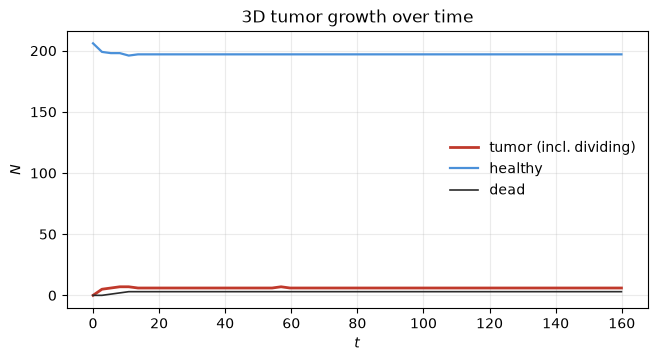

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Axis labels use the symbols of the model equations at the top of the notebook:
# t (time) and N (cell count).
T_LABEL = r"$t$"
N_LABEL = r"$N$"

cell = history.retrieve_columns("cell", ["time", "cell_type"])
counts = (cell.groupby(["time", "cell_type"]).size().unstack(fill_value=0)
          .reindex(sorted(cell["time"].unique())))
tumor_lineage = counts.get("tumor", 0) + counts.get("dividing", 0)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(counts.index, tumor_lineage, color=CELL_TYPE_COLORS["tumor"], lw=2,
        label="tumor (incl. dividing)")
if "healthy" in counts:
    ax.plot(counts.index, counts["healthy"], color=CELL_TYPE_COLORS["healthy"], lw=1.6, label="healthy")
if "dead" in counts and counts["dead"].max() > 0:
    ax.plot(counts.index, counts["dead"], color=CELL_TYPE_COLORS["dead"], lw=1.2, label="dead")
ax.set_xlabel(T_LABEL); ax.set_ylabel(N_LABEL)
ax.set_title("3D tumor growth over time"); ax.legend(frameon=False); ax.grid(alpha=0.25)
plt.show()